In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

student_info = pd.read_csv("../Data/Raw/studentInfo.csv")
student_vle = pd.read_csv("../Data/Raw/studentVle.csv")

print(student_info.shape)
print(student_vle.shape)

(32593, 12)
(10655280, 6)


In [9]:
stem_modules = ["CCC", "DDD", "EEE", "FFF", "GGG"]

stem_student_info = student_info[
    student_info["code_module"].isin(stem_modules)
].copy()

print(stem_student_info.shape)
stem_student_info['final_result'].value_counts()

(23936, 12)


final_result
Pass           8797
Withdrawn      7642
Fail           5194
Distinction    2303
Name: count, dtype: int64

In [10]:
stem_clicks = (
    student_vle.groupby("id_student")["sum_click"]
    .sum()
    .reset_index(name="total_clicks")
)

stem_analysis = stem_student_info.merge(
    stem_clicks,
    on="id_student",
    how="left"
)

stem_analysis.groupby("final_result")["total_clicks"].mean()

final_result
Distinction    3567.533218
Fail            978.124725
Pass           2562.123238
Withdrawn       925.796487
Name: total_clicks, dtype: float64

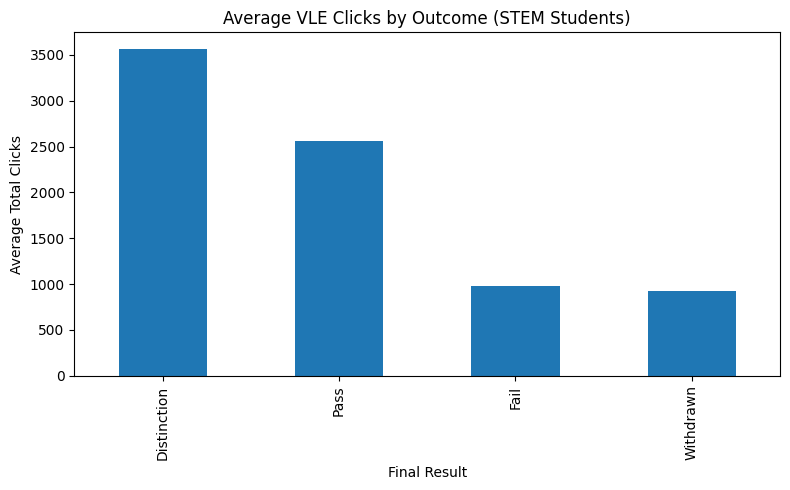

In [11]:
clicks_by_result = (
    stem_analysis
    .groupby("final_result")["total_clicks"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

clicks_by_result.plot(kind="bar")

plt.title("Average VLE Clicks by Outcome (STEM Students)")
plt.ylabel("Average Total Clicks")
plt.xlabel("Final Result")

plt.tight_layout()

plt.savefig(
    "../Figures/stem_clicks_by_outcome.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
stem_analysis.groupby(
    "highest_education"
)["final_result"].value_counts(normalize=True)

highest_education            final_result
A Level or Equivalent        Pass            0.398997
                             Withdrawn       0.298525
                             Fail            0.197088
                             Distinction     0.105390
HE Qualification             Pass            0.398736
                             Withdrawn       0.285793
                             Fail            0.167903
                             Distinction     0.147568
Lower Than A Level           Withdrawn       0.354756
                             Pass            0.323579
                             Fail            0.259736
                             Distinction     0.061928
No Formal quals              Withdrawn       0.415966
                             Fail            0.273109
                             Pass            0.260504
                             Distinction     0.050420
Post Graduate Qualification  Pass            0.362069
                             Distinction

Among STEM students, prior educational attainment was associated with academic outcomes, with students holding higher qualifications demonstrating lower withdrawal and failure rates. However, engagement within the virtual learning environment showed the strongest relationship with success, indicating that behavioral factors may provide a more actionable target for intervention than static demographic characteristics.

In [13]:
stem_analysis.groupby(
    "imd_band"
)["final_result"].value_counts(normalize=True)

imd_band  final_result
0-10%     Withdrawn       0.380187
          Pass            0.295850
          Fail            0.268184
          Distinction     0.055779
10-20     Withdrawn       0.363563
          Pass            0.318823
          Fail            0.259573
          Distinction     0.058041
20-30%    Withdrawn       0.374564
          Pass            0.317953
          Fail            0.229934
          Distinction     0.077549
30-40%    Pass            0.366577
          Withdrawn       0.319985
          Fail            0.227185
          Distinction     0.086253
40-50%    Pass            0.367521
          Withdrawn       0.332906
          Fail            0.210684
          Distinction     0.088889
50-60%    Pass            0.371143
          Withdrawn       0.297262
          Fail            0.237723
          Distinction     0.093872
60-70%    Pass            0.407322
          Withdrawn       0.308156
          Fail            0.180723
          Distinction     0.1038